# Figure S10D-F. Benchmarking CRISPR spacer host prediction

Goal: **maximize species-level host assignment** while retaining high agreement with UHGV.

Host predictions consider **all spacer hits with `N mismatches <= 1`** (joint consensus across 0- and 1-mismatch spacer matches).

Panel order:
- **S10D**: agreement vs number of CRISPR connections (agreement ≥ 0.7; all connection counts)
- **S10E**: agreement vs CRISPR consensus threshold (fixed at ≥ 2 connections)
- **S10F**: proportion annotated at ≥ 2 connections and agreement ≥ 0.7 (UHVDB vs UHGV)

Agreement with UHGV accounts for **GTDB r207 (UHGV) → r226 (UHVDB)** taxon renames via genome-linked taxonomy maps.


In [1]:
### load packages
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

plt.rcParams.update({'font.size': 14})

### Benchmark using UHGV HQ genomes

In [2]:
### Load UHGV metadata
hq_votus = (
    pl.read_csv(
        '../figure_s6/votus_metadata_extended.tsv',
        null_values='NULL',
        separator='\t',
        ignore_errors=True,
        columns=[
            'uhgv_genome',
            'checkv_completeness',
            'viral_confidence',
            'crispr_total_connections',
            'crispr_host_agreement',
            'crispr_host_lineage_gtdb_r207',
        ],
    )
    .filter(
        (pl.col('checkv_completeness') >= 90)
        & (pl.col('viral_confidence') == 'Confident')
    )
    .with_columns(pl.col('crispr_total_connections').cast(pl.Float64))
    .with_columns(pl.col('crispr_host_agreement').cast(pl.Float64))
    .with_columns([
        pl.when(pl.col('crispr_host_lineage_gtdb_r207').str.contains(';s__'))
            .then(pl.col('crispr_host_lineage_gtdb_r207').str.split(';s__').list[-1].str.split(';').list[0])
            .otherwise(None)
            .alias('host_species'),
        pl.when(pl.col('crispr_host_lineage_gtdb_r207').str.contains(';g__'))
            .then(pl.col('crispr_host_lineage_gtdb_r207').str.split(';g__').list[-1].str.split(';').list[0])
            .otherwise(None)
            .alias('host_genus'),
        pl.when(pl.col('crispr_host_lineage_gtdb_r207').str.contains(';f__'))
            .then(pl.col('crispr_host_lineage_gtdb_r207').str.split(';f__').list[-1].str.split(';').list[0])
            .otherwise(None)
            .alias('host_family'),
        pl.when(pl.col('crispr_host_lineage_gtdb_r207').str.contains(';o__'))
            .then(pl.col('crispr_host_lineage_gtdb_r207').str.split(';o__').list[-1].str.split(';').list[0])
            .otherwise(None)
            .alias('host_order'),
        pl.when(pl.col('crispr_host_lineage_gtdb_r207').str.contains(';c__'))
            .then(pl.col('crispr_host_lineage_gtdb_r207').str.split(';c__').list[-1].str.split(';').list[0])
            .otherwise(None)
            .alias('host_class'),
        pl.when(pl.col('crispr_host_lineage_gtdb_r207').str.contains(';p__'))
            .then(pl.col('crispr_host_lineage_gtdb_r207').str.split(';p__').list[-1].str.split(';').list[0])
            .otherwise(None)
            .alias('host_phylum'),
    ])
)

print('Total UHGV HQ vOTUs:', hq_votus['uhgv_genome'].n_unique())
print(
    'Number of UHGV HQ vOTUs with CRISPR host predictions:',
    hq_votus.filter(pl.col('crispr_total_connections') > 0)['uhgv_genome'].n_unique(),
)
print('Number with species-level assignments:', hq_votus.filter(pl.col('host_species').is_not_null())['uhgv_genome'].n_unique())
print('Number with genus-level assignments:', hq_votus.filter(pl.col('host_genus').is_not_null())['uhgv_genome'].n_unique())
print('Number with family-level assignments:', hq_votus.filter(pl.col('host_family').is_not_null())['uhgv_genome'].n_unique())

Total UHGV HQ vOTUs: 57514
Number of UHGV HQ vOTUs with CRISPR host predictions: 51391
Number with species-level assignments: 26250
Number with genus-level assignments: 43084
Number with family-level assignments: 48314


In [3]:
### Harmonize UHGV GTDB r207 host names to UHVDB GTDB r226
### Build r207→r226 maps by joining shared genomes across GTDB taxonomy releases.

from pathlib import Path
import re

GTDB_TAX_DIR = Path('gtdb_tax')
GTDB_TAX_DIR.mkdir(exist_ok=True)

GTDB_FILES = {
    'r207': [
        'https://data.ace.uq.edu.au/public/gtdb/data/releases/release207/207.0/bac120_taxonomy_r207.tsv.gz',
        'https://data.ace.uq.edu.au/public/gtdb/data/releases/release207/207.0/ar53_taxonomy_r207.tsv.gz',
    ],
    'r226': [
        'https://data.ace.uq.edu.au/public/gtdb/data/releases/release226/226.0/bac120_taxonomy_r226.tsv.gz',
        'https://data.ace.uq.edu.au/public/gtdb/data/releases/release226/226.0/ar53_taxonomy_r226.tsv.gz',
    ],
}


def _ensure_gtdb_file(url: str) -> Path:
    dest = GTDB_TAX_DIR / Path(url).name
    if not dest.exists():
        import urllib.request
        print(f'Downloading {dest.name} ...')
        urllib.request.urlretrieve(url, dest)
    return dest


def _load_gtdb_taxonomy(urls):
    frames = []
    for url in urls:
        path = _ensure_gtdb_file(url)
        frames.append(
            pl.read_csv(path, separator='\t', has_header=False, new_columns=['accession', 'lineage'])
        )
    return (
        pl.concat(frames)
        .with_columns(
            pl.col('accession')
            .str.replace(r'^(RS_|GB_)', '')
            .str.replace(r'\.\d+$', '')
            .alias('gid')
        )
    )


def _rank_token(lineage_col: str, rank_prefix: str) -> pl.Expr:
    return (
        pl.when(pl.col(lineage_col).str.contains(f';{rank_prefix}__'))
        .then(
            pl.col(lineage_col)
            .str.split(f';{rank_prefix}__').list.get(-1)
            .str.split(';').list.get(0)
        )
        .otherwise(None)
    )


def build_r207_to_r226_map(rank_prefix: str) -> pl.DataFrame:
    """Majority-vote r207 taxon name → r226 taxon name using shared genome accessions."""
    left = r207_tax.select(['gid', _rank_token('lineage', rank_prefix).alias('r207')])
    right = r226_tax.select(['gid', _rank_token('lineage', rank_prefix).alias('r226')])
    return (
        left.join(right, on='gid', how='inner')
        .filter(pl.col('r207').is_not_null() & pl.col('r226').is_not_null())
        .group_by(['r207', 'r226'])
        .agg(pl.len().alias('n_genomes'))
        .sort(['r207', 'n_genomes'], descending=[False, True])
        .unique(subset=['r207'], keep='first')
        .select(['r207', 'r226', 'n_genomes'])
    )


r207_tax = _load_gtdb_taxonomy(GTDB_FILES['r207'])
r226_tax = _load_gtdb_taxonomy(GTDB_FILES['r226'])

rank_prefix = {'species': 's', 'genus': 'g', 'family': 'f'}
gtdb_maps = {rank: build_r207_to_r226_map(prefix) for rank, prefix in rank_prefix.items()}

for rank, mp in gtdb_maps.items():
    n_changed = mp.filter(pl.col('r207') != pl.col('r226')).height
    print(f'{rank}: {mp.height:,} r207 names mapped; {n_changed:,} renamed in r226')

# Remap UHGV host names into r226 space for fair comparison with UHVDB
hq_votus = hq_votus.with_columns([
    pl.col('host_species')
        .replace_strict(
            dict(zip(gtdb_maps['species']['r207'].to_list(), gtdb_maps['species']['r226'].to_list())),
            default=pl.col('host_species'),
        )
        .alias('host_species_r226'),
    pl.col('host_genus')
        .replace_strict(
            dict(zip(gtdb_maps['genus']['r207'].to_list(), gtdb_maps['genus']['r226'].to_list())),
            default=pl.col('host_genus'),
        )
        .alias('host_genus_r226'),
    pl.col('host_family')
        .replace_strict(
            dict(zip(gtdb_maps['family']['r207'].to_list(), gtdb_maps['family']['r226'].to_list())),
            default=pl.col('host_family'),
        )
        .alias('host_family_r226'),
])

n_species_renamed = hq_votus.filter(
    pl.col('host_species').is_not_null()
    & (pl.col('host_species') != pl.col('host_species_r226'))
).height
print(f'UHGV HQ hosts with remapped species names: {n_species_renamed:,}')


def hosts_match_expr(uhgv_col: str, uhvdb_col: str = 'top_taxonomy', rank: str = 'species') -> pl.Expr:
    """Exact match, r226-mapped match, or shared GTDB species placeholder ID (spXXXXXXXXX)."""
    exact = pl.col(uhgv_col) == pl.col(uhvdb_col)
    if rank == 'species':
        uhgv_spid = pl.col(uhgv_col).str.extract(r'sp(\d{9})', 1)
        uhvdb_spid = pl.col(uhvdb_col).str.extract(r'sp(\d{9})', 1)
        spid = uhgv_spid.is_not_null() & (uhgv_spid == uhvdb_spid)
        return exact | spid
    return exact


species: 62,153 r207 names mapped; 8,859 renamed in r226
genus: 16,099 r207 names mapped; 1,195 renamed in r226
family: 3,990 r207 names mapped; 305 renamed in r226
UHGV HQ hosts with remapped species names: 5,473


In [4]:
### Build UHVDB CRISPR host predictions
### Mirrors toolkit/bin/uhvdb_crisprhost.py consensus logic

CRISPR_TSV = '../figure_1/uhgv_hq_hc_results/uhvdb_2026-03-23/uhvdb_crispr.tsv.gz'
MAPPING_TSV = '../figure_1/uhgv_hq_hc_results/uhvdb_2026-03-23/uhvdb_mapping.tsv.gz'
RANKS = ['species', 'genus', 'family']
MIN_AGREEMENT_DEFAULT = 0.7

mapping = (
    pl.scan_csv(MAPPING_TSV, separator='\t')
    .rename({'original_id': 'column_1', 'new_id': 'column_2'})
    .with_columns(pl.col('column_1').str.replace(r'\|provirus.*', ''))
    .collect()
)

crispr_lf = pl.scan_csv(CRISPR_TSV, separator='\t').select(
    ['uhvdb_id', 'species', 'genus', 'family', 'N mismatches']
)


def assign_crispr_hosts(lf, max_mismatches, ranks=RANKS):
    """Consensus host calls at species/genus/family for one mismatch cutoff."""
    base = lf.filter(pl.col('N mismatches') <= max_mismatches)
    parts = []
    for rank in ranks:
        parts.append(
            base
            .filter(pl.col(rank).is_not_null() & (pl.col(rank).str.strip_chars() != ''))
            .group_by(['uhvdb_id', rank])
            .agg(pl.len().alias('connections'))
            .group_by('uhvdb_id')
            .agg([
                pl.col('connections').sum().alias('total_connections'),
                pl.col('connections').max().alias('max_connections'),
                pl.col(rank).sort_by('connections', descending=True).first().alias('top_taxonomy'),
            ])
            .with_columns([
                (pl.col('max_connections') / pl.col('total_connections')).alias('agreement'),
                pl.lit(rank).alias('rank'),
            ])
        )
    return pl.concat(parts).collect(engine='streaming')


print('Building consensus for spacer hits with <= 1 mismatch...')
preds_1mm = assign_crispr_hosts(crispr_lf, max_mismatches=1)

uhvdb_host_predictions = (
    preds_1mm
    .with_columns(pl.lit('<=1mm').alias('evidence'))
    .join(mapping, left_on='uhvdb_id', right_on='column_2', how='inner')
)

n_species = uhvdb_host_predictions.filter(
    (pl.col('rank') == 'species') & (pl.col('agreement') >= MIN_AGREEMENT_DEFAULT)
)['uhvdb_id'].n_unique()
print(
    f"{uhvdb_host_predictions.height:,} rows, "
    f"{uhvdb_host_predictions['uhvdb_id'].n_unique():,} viruses, "
    f'{n_species:,} with species call @≥{MIN_AGREEMENT_DEFAULT}'
)

# Shared denominator: HQ genomes present in both UHGV and UHVDB mappings
both_methods = set(
    mapping.join(hq_votus, left_on='column_1', right_on='uhgv_genome', how='inner')['column_1']
)
hq_both = hq_votus.filter(pl.col('uhgv_genome').is_in(both_methods))
n_hq_both = hq_both['uhgv_genome'].n_unique()
print('Number of HQ vOTUs present in UHGV and UHVDB (denominator):', n_hq_both)
uhvdb_host_predictions.head(3)


Building consensus for spacer hits with <= 1 mismatch...
433,963 rows, 144,722 viruses, 59,311 with species call @≥0.7
Number of HQ vOTUs present in UHGV and UHVDB (denominator): 51406


uhvdb_id,total_connections,max_connections,top_taxonomy,agreement,rank,evidence,column_1
str,u32,u32,str,f64,str,str,str
"""UHVDB-138936""",46,31,"""Agathobacter rectalis""",0.673913,"""species""","""<=1mm""","""UHGV-1488927"""
"""UHVDB-141932""",1,1,"""Agathobacter sp900317585""",1.0,"""species""","""<=1mm""","""UHGV-1502691"""
"""UHVDB-157225""",4502,1728,"""Lachnospira eligens_A""",0.383829,"""species""","""<=1mm""","""UHGV-1541117"""


In [5]:
### Species-level coverage & UHGV agreement (raw vs GTDB-harmonized)
### Focus: maximize fraction of viruses with a species host call

AGREE_THRESH = 0.7

species_preds = (
    uhvdb_host_predictions
    .filter(pl.col('rank') == 'species')
    .filter(pl.col('agreement') >= AGREE_THRESH)
    .filter(pl.col('column_1').is_in(both_methods))
)

joined_raw = (
    hq_both
    .filter(pl.col('host_species').is_not_null())
    .join(species_preds, left_on='uhgv_genome', right_on='column_1', how='left')
)
joined_mapped = (
    hq_both
    .filter(pl.col('host_species_r226').is_not_null())
    .join(species_preds, left_on='uhgv_genome', right_on='column_1', how='left')
)

n_assigned = species_preds['column_1'].n_unique()
n_ref_raw = joined_raw.height

tp_raw = joined_raw.filter(hosts_match_expr('host_species', rank='species')).height
fp_raw = joined_raw.filter(
    (~hosts_match_expr('host_species', rank='species')) & pl.col('top_taxonomy').is_not_null()
).height
tp_map = joined_mapped.filter(hosts_match_expr('host_species_r226', rank='species')).height
fp_map = joined_mapped.filter(
    (~hosts_match_expr('host_species_r226', rank='species')) & pl.col('top_taxonomy').is_not_null()
).height

species_coverage_df = pl.DataFrame([{
    'n_viruses_with_species_host': n_assigned,
    'prop_viruses_with_species_host': n_assigned / n_hq_both,
    'precision_vs_uhgv_raw': tp_raw / (tp_raw + fp_raw) if (tp_raw + fp_raw) else 0,
    'precision_vs_uhgv_gtdb_mapped': tp_map / (tp_map + fp_map) if (tp_map + fp_map) else 0,
    'n_uhgv_species_refs': n_ref_raw,
    'tp_raw': tp_raw,
    'fp_raw': fp_raw,
    'tp_mapped': tp_map,
    'fp_mapped': fp_map,
}])
print(f'Total UHGV HQ vOTUs present in UHGV and UHVDB (denominator): {n_hq_both:,}')
display(species_coverage_df)

best = species_coverage_df.row(0, named=True)
print(
    f"Species coverage (≤1 mismatch): {best['n_viruses_with_species_host']:,} viruses "
    f"({best['prop_viruses_with_species_host']:.1%}); "
    f"precision raw={best['precision_vs_uhgv_raw']:.3f}, "
    f"GTDB-mapped={best['precision_vs_uhgv_gtdb_mapped']:.3f}"
)


Total UHGV HQ vOTUs present in UHGV and UHVDB (denominator): 51,406


n_viruses_with_species_host,prop_viruses_with_species_host,precision_vs_uhgv_raw,precision_vs_uhgv_gtdb_mapped,n_uhgv_species_refs,tp_raw,fp_raw,tp_mapped,fp_mapped
i64,f64,f64,f64,i64,i64,i64,i64,i64
22075,0.429425,0.849711,0.884209,23501,13213,2337,14738,1930


Species coverage (≤1 mismatch): 22,075 viruses (42.9%); precision raw=0.850, GTDB-mapped=0.884


In [6]:
### Agreement vs number of CRISPR connections (S10D; fixed agreement >= 0.7)
### Uses GTDB r226-harmonized UHGV host names

recalls = []
precisions = []
f1s = []
props = []
ranks = []
num_hits = []

host_col = {
    'species': 'host_species_r226',
    'genus': 'host_genus_r226',
    'family': 'host_family_r226',
}

for rank in RANKS:
    uhgv_new = (
        uhvdb_host_predictions
        .filter(pl.col('rank') == rank)
        .filter(pl.col('agreement') >= 0.7)
        .filter(pl.col('column_1').is_in(both_methods))
    )

    uhgv_uhvdb_join = (
        hq_both
        .filter(pl.col(host_col[rank]).is_not_null())
        .join(uhgv_new, left_on='uhgv_genome', right_on='column_1', how='left')
    )

    for num_hit in [1, 2, 3, 5, 10, 20, 50]:
        match = hosts_match_expr(host_col[rank], rank=rank)
        tp = uhgv_uhvdb_join.filter(match & (pl.col('total_connections') >= num_hit)).height
        fp = uhgv_uhvdb_join.filter(
            (~match) & (~pl.col('top_taxonomy').is_null()) & (pl.col('total_connections') >= num_hit)
        ).height
        fn = uhgv_uhvdb_join.filter(
            pl.col('top_taxonomy').is_null() | (pl.col('total_connections') < num_hit)
        ).height

        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        recalls.append(recall)
        precisions.append(precision)
        f1s.append(f1)
        props.append(
            uhgv_new.filter(pl.col('total_connections') >= num_hit)
            .select('column_1').n_unique() / n_hq_both
        )
        ranks.append(rank)
        num_hits.append(num_hit)

connections_df = pl.DataFrame({
    'rank': ranks,
    'num_hits': num_hits,
    'recall': recalls,
    'precision': precisions,
    'f1_score': f1s,
    'proportion_assigned': props,
})


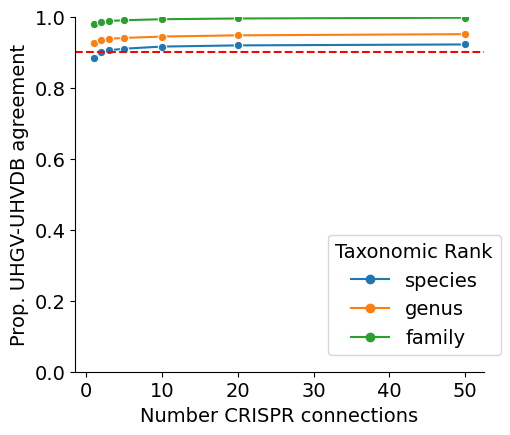

In [7]:
### Plot agreement vs CRISPR connection count (S10D)
g = sns.relplot(
    data=connections_df.to_pandas(),
    x='num_hits',
    y='precision',
    hue='rank',
    kind='line',
    markers=True,
    height=4.5,
    aspect=1.2,
    marker='o'
)
g.set_axis_labels('Number CRISPR connections', 'Prop. UHGV-UHVDB agreement')
g.set(ylim=(0, 1))
for ax in g.axes.flat:
    ax.axhline(y=0.9, color='r', linestyle='--')
sns.move_legend(g, loc='lower right', bbox_to_anchor=(0.82, 0.18), title='Taxonomic Rank', frameon=True)
plt.show()


In [8]:
### Agreement vs CRISPR consensus threshold (S10E)
### Fixed at >= 2 connections; uses GTDB r226-harmonized UHGV host names for comparison

recalls = []
precisions = []
f1s = []
props = []
ranks = []
agreements = []

MIN_CONNECTIONS = 1

host_col = {
    'species': 'host_species_r226',
    'genus': 'host_genus_r226',
    'family': 'host_family_r226',
}

for rank in RANKS:
    for agreement in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:
        uhgv_new = (
            uhvdb_host_predictions
            .filter(pl.col('rank') == rank)
            .filter(pl.col('agreement') >= agreement)
            .filter(pl.col('total_connections') >= MIN_CONNECTIONS)
            .filter(pl.col('column_1').is_in(both_methods))
        )

        uhgv_uhvdb_join = (
            hq_both
            .filter(pl.col(host_col[rank]).is_not_null())
            .join(uhgv_new, left_on='uhgv_genome', right_on='column_1', how='left')
        )

        match = hosts_match_expr(host_col[rank], rank=rank)
        tp = uhgv_uhvdb_join.filter(match).height
        fp = uhgv_uhvdb_join.filter((~match) & (~pl.col('top_taxonomy').is_null())).height
        fn = uhgv_uhvdb_join.filter(pl.col('top_taxonomy').is_null()).height

        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        recalls.append(recall)
        precisions.append(precision)
        f1s.append(f1)
        props.append(uhgv_new.select('column_1').n_unique() / n_hq_both)
        ranks.append(rank)
        agreements.append(agreement)

agreement_df = pl.DataFrame({
    'rank': ranks,
    'recall': recalls,
    'precision': precisions,
    'f1_score': f1s,
    'proportion_assigned': props,
    'agreement_threshold': agreements,
})


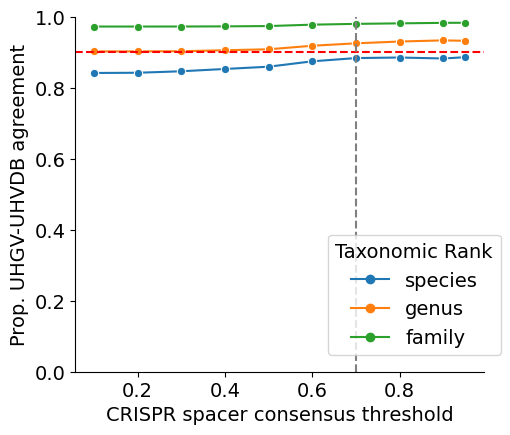

In [9]:
### Plot agreement vs consensus threshold (S10E)
g = sns.relplot(
    data=agreement_df.to_pandas(),
    x='agreement_threshold',
    y='precision',
    hue='rank',
    kind='line',
    markers=True,
    height=4.5,
    aspect=1.2,
    marker='o'
)
g.set_axis_labels('CRISPR spacer consensus threshold', 'Prop. UHGV-UHVDB agreement')
g.set(ylim=(0, 1))
for ax in g.axes.flat:
    ax.axhline(y=0.9, color='r', linestyle='--')
    ax.axvline(x=0.7, color='grey', linestyle='--')
sns.move_legend(g, loc='lower right', bbox_to_anchor=(0.82, 0.18), title='Taxonomic Rank', frameon=True)
plt.show()


In [10]:
### HQ genomes shared across UHGV metadata and UHVDB mappings
# Defined earlier (after CRISPR predictions) as both_methods / hq_both / n_hq_both
print('Number of HQ vOTUs present in UHGV and UHVDB (denominator):', n_hq_both)

Number of HQ vOTUs present in UHGV and UHVDB (denominator): 51406


rank,proportion_annotated,Method,num_annotated,num_total
str,f64,str,i64,i64
"""species""",0.429425,"""UHVDB""",22075,51406
"""species""",0.457165,"""UHGV""",23501,51406
"""genus""",0.748979,"""UHVDB""",38502,51406
"""genus""",0.752111,"""UHGV""",38663,51406
"""family""",0.836323,"""UHVDB""",42992,51406
"""family""",0.844201,"""UHGV""",43397,51406


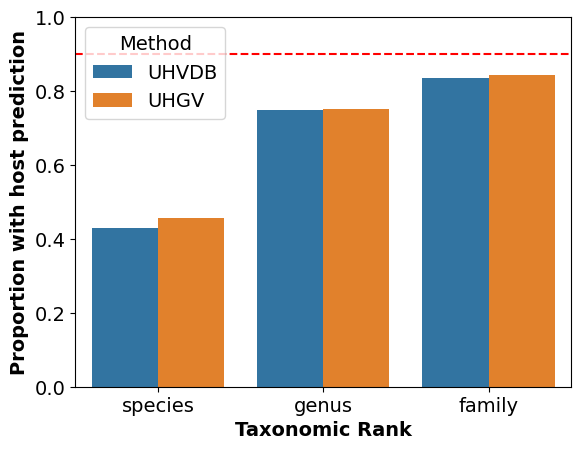

In [11]:
### Proportion annotated at each rank (S10F; fixed: >= 2 connections, agreement >= 0.7)
MIN_CONNECTIONS = 1
hq_total = n_hq_both

props = []
methods = []
ranks = []
num_annotated = []
num_total = []

for rank in RANKS:
    # UHVDB CRISPR-derived (≤1 mismatch)
    uhvdb_annotated = (
        uhvdb_host_predictions
        .filter(pl.col('column_1').is_in(both_methods))
        .filter(pl.col('rank') == rank)
        .filter(pl.col('agreement') >= MIN_AGREEMENT_DEFAULT)
        .filter(pl.col('total_connections') >= MIN_CONNECTIONS)
        .select('column_1')
        .unique()
        .height
    )
    props.append(uhvdb_annotated / hq_total if hq_total > 0 else 0)
    methods.append('UHVDB')
    ranks.append(rank)
    num_annotated.append(uhvdb_annotated)
    num_total.append(hq_total)

    # Original UHGV CRISPR annotations
    uhgv_old = (
        hq_both
        .filter(pl.col(f'host_{rank}').is_not_null())
        .filter(pl.col('crispr_host_agreement') >= MIN_AGREEMENT_DEFAULT)
        .filter(pl.col('crispr_total_connections') >= MIN_CONNECTIONS)
        .select('uhgv_genome')
        .unique()
        .height
    )
    props.append(uhgv_old / hq_total if hq_total > 0 else 0)
    methods.append('UHGV')
    ranks.append(rank)
    num_annotated.append(uhgv_old)
    num_total.append(hq_total)

annotation_rate_df = pl.DataFrame({
    'rank': ranks,
    'proportion_annotated': props,
    'Method': methods,
    'num_annotated': num_annotated,
    'num_total': num_total,
})
display(annotation_rate_df)

sns.barplot(
    data=annotation_rate_df.to_pandas(),
    x='rank',
    y='proportion_annotated',
    hue='Method',
)
plt.xlabel('Taxonomic Rank', fontdict={'fontweight': 'bold'})
plt.ylabel('Proportion with host prediction', fontdict={'fontweight': 'bold'})
plt.ylim(0, 1)
plt.axhline(y=0.9, color='r', linestyle='--')
plt.legend(title='Method')
plt.show()


In [12]:
### Species with the most residual disagreements after GTDB r207→r226 harmonization
DISAGREE_RANK = 'species'
DISAGREE_AGREEMENT = 0.7
TOP_N = 20

uhgv_new = (
    uhvdb_host_predictions
    .filter(pl.col('agreement') >= DISAGREE_AGREEMENT)
    .filter(pl.col('rank') == DISAGREE_RANK)
)

focus_disagreements = (
    hq_votus
    .filter(pl.col('host_species_r226').is_not_null())
    .join(uhgv_new, left_on='uhgv_genome', right_on='column_1', how='inner')
    .filter(~hosts_match_expr('host_species_r226', rank='species'))
    .select([
        pl.col('uhgv_genome'),
        pl.col('host_species').alias('uhgv_species_r207'),
        pl.col('host_species_r226').alias('uhgv_species_r226'),
        pl.col('top_taxonomy').alias('uhvdb_species_r226'),
        'total_connections',
        'agreement',
        'evidence',
    ])
)

top_uhvdb_disagree_species = (
    focus_disagreements
    .group_by('uhvdb_species_r226')
    .agg([
        pl.len().alias('n_disagreements'),
        pl.col('uhgv_species_r226').n_unique().alias('n_unique_uhgv_species'),
        pl.col('uhgv_species_r226').mode().first().alias('most_common_uhgv_partner_r226'),
        pl.col('total_connections').median().alias('median_connections'),
        pl.col('agreement').median().alias('median_agreement'),
    ])
    .sort('n_disagreements', descending=True)
)

top_uhgv_disagree_species = (
    focus_disagreements
    .group_by(['uhgv_species_r207', 'uhgv_species_r226'])
    .agg([
        pl.len().alias('n_disagreements'),
        pl.col('uhvdb_species_r226').n_unique().alias('n_unique_uhvdb_species'),
        pl.col('uhvdb_species_r226').mode().first().alias('most_common_uhvdb_partner'),
    ])
    .sort('n_disagreements', descending=True)
)

print(f'Total residual disagreements (≤1 mismatch, GTDB-harmonized): {focus_disagreements.height:,}')
print(f'\nTop {TOP_N} UHVDB species with the most disagreements:')
display(top_uhvdb_disagree_species.head(TOP_N))
print(f'\nTop {TOP_N} UHGV species with the most disagreements:')
display(top_uhgv_disagree_species.head(TOP_N))


Total residual disagreements (≤1 mismatch, GTDB-harmonized): 1,930

Top 20 UHVDB species with the most disagreements:


uhvdb_species_r226,n_disagreements,n_unique_uhgv_species,most_common_uhgv_partner_r226,median_connections,median_agreement
str,u32,u32,str,f64,f64
"""Ruminococcus_E bromii_B""",293,3,"""Ruminococcoides intestinale""",1870.0,0.921939
"""Salmonella enterica""",154,27,"""Klebsiella pneumoniae""",654.5,0.908617
"""Ruminococcus_E intestinalis""",111,2,"""Ruminococcoides intestinalis""",857.0,0.870324
"""Faecalibacterium prausnitzii_D""",64,3,"""Faecalibacterium taiwanense""",485.0,0.749405
"""Ruminococcus_E sp934476515""",61,1,"""Ruminococcoides intestinihomin…",60.0,0.960526
…,…,…,…,…,…
"""Phascolarctobacterium_A succin…",19,1,"""Phascolarctobacterium_A succin…",157.0,0.796
"""Methanobrevibacter_A smithii""",18,1,"""Methanocatella smithii""",405.5,0.897502
"""CAG-103 sp000432375""",15,9,"""CAG-103 sp900543625""",1.0,1.0



Top 20 UHGV species with the most disagreements:


uhgv_species_r207,uhgv_species_r226,n_disagreements,n_unique_uhvdb_species,most_common_uhvdb_partner
str,str,u32,u32,str
"""Ruminococcus_E bromii_B""","""Ruminococcoides intestinale""",292,2,"""Ruminococcus_E bromii_B"""
"""Ruminococcus_E sp003526955""","""Ruminococcoides intestinalis""",111,2,"""Ruminococcus_E intestinalis"""
"""Dysosmobacter sp001916835""","""Oscillibacter segnis""",64,4,"""Dysosmobacter segnis"""
"""Faecalibacterium prausnitzii_D""","""Faecalibacterium taiwanense""",63,2,"""Faecalibacterium prausnitzii_D"""
"""Ruminococcus_E sp900314705""","""Ruminococcoides intestinihomin…",63,3,"""Ruminococcus_E sp934476515"""
…,…,…,…,…
"""Lachnospira rogosae_A""","""Lachnospira rogosae""",25,1,"""Lachnospira pectinoschiza_A"""
"""Streptococcus pneumoniae""","""Streptococcus pneumoniae""",22,21,"""51-20 sp001917175"""
"""Anaerotignum faecicola""","""Anaerotignum_A faecicola""",21,1,"""Anaerotignum faecicola"""
